In [1]:
from functools import partial

import pandas as pd
import jax
import jax.tree_util as jtu
import jax.numpy as jnp

from functools import partial

import equinox as eqx
from equinox.nn import MLP, Identity, Linear

from jaxtyping import PyTree, Array
from typing import Callable

import matplotlib.pyplot as plt


In [2]:
jax.config.update("jax_disable_jit", False)
jax.config.update("jax_debug_nans", True)
jax.config.update("jax_debug_infs", True)
jax.config.update("jax_enable_x64", True)

# Parameter and coefficients

In [3]:
# Number of time step
nt = 100

# Time duration
t_length = 10.

# Time step
dt = t_length / nt

# The maximum age step
τ_max = nt

# The old-water concentration
C_old = jnp.array([0.0]) # [mg/l]

# The first-order reaction rate constant
k1 = jnp.array([0.0])

# The equilibrium concentration
C_eq = jnp.array([0.0]) # [mg/o]

# Fractionation
α_Q, α_ET = 1., 0.


# Flow and solutes in/out

In [4]:
pulse_start1 = 0.05
pulse_end1 = 0.45

pulse_start2 = 5.25
pulse_end2 = 5.45

C_tracer_input1 = 0.5
C_tracer_input2 = 1.5
Q_steady = 1.
Storage_vol = 0.1

data_df = pd.DataFrame(index=jnp.arange(nt) * dt)
data_df['Q'] = Q_steady
data_df['ET'] = 0.
data_df['J'] = Q_steady
data_df['C_J'] = 0
data_df.loc[pulse_start1:pulse_end1, 'C_J'] = C_tracer_input1
data_df.loc[pulse_start2:pulse_end2, 'C_J'] = C_tracer_input2
data_df.loc[pulse_start1:pulse_end1, 'J'] = Q_steady * 2
data_df.loc[pulse_start1:pulse_end1, 'Q'] = Q_steady / 20.


/tmp/ipykernel_1135772/2955467266.py:17: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df.loc[pulse_start1:pulse_end1, 'C_J'] = C_tracer_input1


<Axes: >

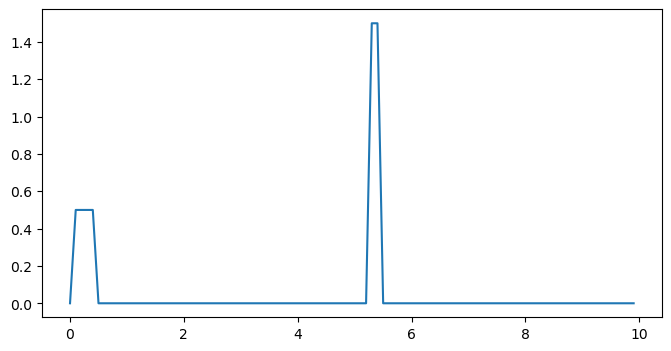

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))
data_df['C_J'].plot(ax=ax)


# SAS functions

In [6]:
# The base class
class SASBase(eqx.Module):
    loc: Array
    scale: Array
    
    def __init__(self, loc=0.0, scale=1.0):
        self.loc = jnp.array(loc)
        self.scale = jnp.array(scale)
    
    def pdf(self, Si, x):
        # Return PDF
        raise Exception('Not implemented')
    
    def __call__(self, Si, x):
        # Return CDF:
        raise Exception('Not implemented')


In [7]:
# The base class
class SAS_null(SASBase):
    loc: Array
    scale: Array
    
    def pdf(self, Si, x):
        # Return PDF
        return 0.
    
    def __call__(self, Si, x):
        # Return CDF:
        return 0.


In [8]:
# Gamme distribution
class SAS_Gamma(SASBase):
    a: Array
    # func: Callable

    # TODO: the minimum scaled y is needed to avoid
    # the FloatingPointError in jit operations!
    
    def __init__(self, a, loc=0.0, scale=1.0):
        super().__init__(loc, scale)
        self.a = jnp.array(a)
        # self.func = MLP(in_size=1, out_size=2, key=jax.random.key(42), **mlp_kwargs)
    
    def pdf(self, Si, x=None):
        a, loc, scale = self.a, self.loc, self.scale
        y = (Si - loc) / scale
        y = jax.lax.max(1e-20, y)
        return jax.scipy.stats.gamma.pdf(y, a, loc=0., scale=1.)
    
    def __call__(self, Si, x=None):
        a, loc, scale = self.a, self.loc, self.scale
        y = (Si - loc) / scale
        y = jax.lax.max(1e-20, y)
        return jax.scipy.stats.gamma.cdf(y, a, loc=0., scale=1.)


In [9]:
# Beta distribution
class SAS_Beta(SASBase):
    a: Array
    b: Array
    
    def __init__(self, a, b, loc=0.0, scale=1.0):
        super().__init__(loc, scale)
        self.a, self.b = jnp.array(a), jnp.array(b)
    
    def pdf(self, Si, x=None):
        a, b, loc, scale = self.a, self.b, self.loc, self.scale
        return jax.scipy.stats.beta.pdf(Si, a, b, loc, scale)
    
    def __call__(self, Si, x=None):
        a, b, loc, scale = self.a, self.b, self.loc, self.scale
        return jax.scipy.stats.beta.cdf(Si, a, b, loc, scale)


In [10]:
# Kumaraswamy distribution 
class SAS_Kumaraswamy(SASBase):
    a: Array
    b: Array
    
    def __init__(self, a, b, loc=0.0, scale=1.0):
        super().__init__(loc, scale)
        self.a, self.b = jnp.array(a), jnp.array(b)
    
    def pdf(self, Si, x=None):
        a, b, loc, scale = self.a, self.b, self.loc, self.scale
        y = (Si - loc) / scale
        y = jax.lax.min(jax.lax.max(0., y), 1.)
        return a * b * y ** (a-1) * (1-y**a) ** (b-1)
    
    def __call__(self, Si, x=None):
        # Return CDF:
        a, b, loc, scale = self.a, self.b, self.loc, self.scale
        y = (Si - loc) / scale
        y = jax.lax.min(jax.lax.max(0., y), 1.)
        return 1. - (1. - y**a) ** b


In [11]:
# Mixture density network
class SAS_MDN(SASBase):
    m: eqx.Module
    m_α: eqx.Module
    m_μ: eqx.Module
    m_σ: eqx.Module
    # pdf_func: Callable
    # cdf_func: Callable
    
    def __init__(self, n_input, n_hidden, n_mixture, key, loc=0., scale=1., **mlp_kwargs):
        super().__init__(loc, scale)
        key1, key2, key3, key4 = jax.random.split(key,4)
        
        # MLP model for predicting the hidden states
        # n_mlp_output = (n_output+2) * n_mixture
        self.m = MLP(in_size=n_input, out_size=n_hidden, key=key1, **mlp_kwargs)
        
        # MLP model for predicting α, μ, and σ
        self.m_α = Linear(in_features=n_hidden, out_features=n_mixture, key=key2)
        self.m_μ = Linear(in_features=n_hidden, out_features=n_mixture, key=key3)
        self.m_σ = Linear(in_features=n_hidden, out_features=n_mixture, key=key4)
        
        # # PDF function of mixture distributions 
        # self.pdf_func = jax.scipy.stats.norm.pdf
        
        # # CDF function of mixture distributions 
        # self.cdf_func = jax.scipy.stats.norm.cdf
    
    def get_param(self, x):
        # Calculate the weights, mean, and standard deviation of the mixture distributions
        z = self.m(x)  # shape: (n_hidden,)
        z_α, z_μ, z_σ = self.m_α(z), self.m_μ(z), self.m_σ(z) # shape: (n_mixture,) (n_mixture,) (n_mixture)
        
        # The weights (n_mixture,)
        α = jax.nn.softmax(z_α)
        
        # The mean (n_mixture,)
        μ = z_μ
        
        # The standard deviation (n_mixture,)
        σ = jnp.exp(z_σ)
        
        return α, μ, σ
    
    def pdf(self, Si, x):
        y = (Si - self.loc) / self.scale
        α, μ, σ = self.get_param(x)
        pdfs = jax.vmap(jax.scipy.stats.norm.pdf, in_axes=(None,0,0))(y, μ, σ)
        return jnp.sum(jnp.dot(α, pdfs))
    
    def __call__(self, Si, x):
        y = (Si - self.loc) / self.scale
        α, μ, σ = self.get_param(x)
        cdfs = jax.vmap(jax.scipy.stats.norm.cdf, in_axes=(None,0,0))(y, μ, σ)
        return jnp.sum(jnp.dot(α, cdfs))


# SAS-based transport forward function

In [12]:
# Compute mQ -- mass loss with flow
def compute_mQ(sT, mT, α, Q_t, pQ):
    # sT, mT, α, Q_t, pQ: (1,), (1,), (1,), (1,), (1,)
    # return mT / sT * (α * Q_t * pQ)
    # return jnp.where(sT == 0.0, 0.0, mT / sT * (α * Q_t * pQ))
    part_a = mT * (α * Q_t * pQ)
    y = jnp.where(sT == 0.0, 1.0, sT)
    y = jnp.where(sT == 0.0, 0.0, 1./ y)
    return part_a * y

# Compute mR -- Reaction rate
def compute_mR(sT, mT, k1, C_eq):
    # sT, mT, k1, C_eq: (1,), (1,), (1,), (1,)
    return k1 * (C_eq*sT - mT)

compute_mR_vec = jax.vmap(compute_mR, in_axes=(None,0,0,0))


In [13]:
def f(sTmT, ST, dt, 
      J_τ_t, C_J_τ_t, Q_t, ET_t, 
      sas_Q, sas_ET, sas_arg_Q, sas_arg_ET, 
      α_Q, α_ET, k1, C_eq
):
    # sTmT: (1+nm,)
    # ST: (1,)
    # dt: (1,)
    # J_τ_t: (1,)
    # C_J_τ_t: (nm,)
    # Q_t: (1,)
    # ET_t: (1,)
    # α_Q: (1,)
    # α_ET: (1,)
    # sas_Q: (1,)
    # sas_arg_Q: (1,)
    # sas_ET: (1,)
    # sas_arg_ET: (1,)
    # k1: (nm,)
    # C_eq: (nm,)
    
    sT = sTmT[0] # (1,)
    mT = sTmT[1:] # (nm,)
    
    # Calculate the pQ, mQ, and mR
    PQ1, PQ2 = sas_Q(ST+sT*dt, sas_arg_Q), sas_Q(ST, sas_arg_Q)
    pQ = (PQ1 - PQ2) / dt
    PET1, PET2 = sas_ET(ST+sT*dt, sas_arg_ET), sas_ET(ST, sas_arg_ET)
    pET = (PET1 - PET2) / dt
    mQ = compute_mQ(sT, mT, α_Q, Q_t, pQ) # (nm,)
    mET = compute_mQ(sT, mT, α_ET, ET_t, pET) # (nm,)

    pQET = jnp.array([pQ, pET])  # (2,)
    mQET = jnp.array([mQ, mET]).T  # (nm, 2)
    
    # Calculate mR
    mR = compute_mR_vec(sT, mT, k1, C_eq)  # (nm,)
    
    # Update the change of sT and mT
    δs = (J_τ_t - Q_t * pQ * dt - ET_t * pET * dt) / dt  # (1,)

    # Update the change of sT and mT
    δm = (J_τ_t * C_J_τ_t - mQ * dt - mET * dt + mR * dt) / dt  # (nm,)

    # print(pQET.shape)
    return jnp.concat([jnp.array([δs]), δm]), pQET, mQET, mR


fvec = jax.vmap(
    f, in_axes=(0,0,None,0,0,0,0,None,None,0,0,
                None,None,None,None)
)


# SAS transport solver/functions

In [14]:
# !!!! Note that the usage of nn.relu would affect the accuracy of implicit differentiation
def solve_step_euler(states, ST_top, ST_bot, dt, *args, f):
    # states: (nt, ns)
    # ST_top, ST_bot: (nt)

    # Note: we use relu to make sure the updated states are non-zero
    ST = ST_top
    r, pQET, mQET, mR = f(states, ST, dt, *args)

    # states_new = states + r * dt
    states_new = jax.nn.relu(states + r * dt)

    return states_new, pQET, mQET, mR


In [15]:
# !!!! Note that the usage of nn.relu would affect the accuracy of implicit differentiation
def solve_step_rk2(states, ST_top, ST_bot, dt, *args, f):
    # states: (nt, ns)
    # ST_top, ST_bot: (nt)

    # Note: we use relu to make sure the updated states are non-zero
    ST1 = ST_top
    states1 = states
    r1, pQET1, mQET1, mR1 = f(states1, ST1, dt, *args)
    
    ST2 = ST_bot
    states2 = jax.nn.relu(states+1.*r1*dt)
    # states2 = states+1.*r1*dt
    r2, pQET2, mQET2, mR2 = f(states2, ST2, dt, *args)

    pQET = 1./2 * (pQET1 + pQET2)
    mQET = 1./2 * (mQET1 + mQET2)
    mR = 1./2 * (mR1 + mR2)
    states_new = jax.nn.relu(states + (r1 + r2)/2. * dt)
    # states_new = states + (r1 + r2)/2. * dt

    return states_new, pQET, mQET, mR


In [16]:
# !!!! Note that the usage of nn.relu would affect the accuracy of implicit differentiation
def solve_step_rk4(states, ST_top, ST_bot, dt, *args, f):
    # states: (nt, ns)
    # ST_top, ST_bot: (nt)

    # Note: we use relu to make sure the updated states are non-zero
    ST1 = ST_top
    states1 = states
    r1, pQET1, mQET1, mR1 = f(states1, ST1, dt, *args)
    # jax.debug.print('r1: {x}', x=r1)
    
    ST2 = ST_top/2 + ST_bot/2
    states2 = jax.nn.relu(states+0.5*r1*dt)
    # states2 = states+0.5*r1*dt
    r2, pQET2, mQET2, mR2 = f(states2, ST2, dt, *args)
    # jax.debug.print('r2: {x}', x=r2)
    
    ST3 = ST_top/2 + ST_bot/2
    states3 = jax.nn.relu(states+0.5*r2*dt)
    # states3 = states+0.5*r2*dt
    r3, pQET3, mQET3, mR3 = f(states3, ST3, dt, *args)
    # jax.debug.print('r3: {x}', x=r3)
    
    ST4 = ST_bot
    states4 = jax.nn.relu(states+1.*r3*dt)
    # states4 = states+1.*r3*dt
    r4, pQET4, mQET4, mR4 = f(states4, ST4, dt, *args)
    # jax.debug.print('r4: {x}', x=r4)

    # states_new = states + 1./6 * (r1 + 2 * r2 + 2 * r3 + r4) * dt
    states_new = jax.nn.relu(states + 1./6 * (r1 + 2 * r2 + 2 * r3 + r4) * dt)
    pQET = 1./6 * (pQET1 + 2 * pQET2 + 2 * pQET3 + pQET4)
    mQET = 1./6 * (mQET1 + 2 * mQET2 + 2 * mQET3 + mQET4)
    mR = 1./6 * (mR1 + 2 * mR2 + 2 * mR3 + mR4)

    # jax.debug.print('states_new: {x}', x=states_new)

    return states_new, pQET, mQET, mR


In [17]:
def solve_ttd_sTmT(
    f, solver,
    J_full, C_J, Q, ET, dt,
    sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
    sas_Q, sas_ET,
    α_Q, α_ET, k1, C_eq, 
    # *, 
    # solver, f
):
    # J_full: (nτ, nt)
    # C_J: (nt,)
    # Q: (nt,)
    # ET: (nt,)
    # dt: (1,)
    # sTmT_0: (nt, 1+nm)
    # ST_top_0: (nt,)
    # ST_bot_0: (nt,)
    # sTmT_init: (nτ, 1+nm)
    # sas_Q, sas_ET: (1,)
    # α_Q, α_ET: (1,)
    # k1, C_eq: (nm,)
    
    sas_funcs = [sas_Q, sas_ET]
    other_args = [α_Q, α_ET, k1, C_eq]
    
    def step_τ(states, x):
        # sTmT_init_τ : (1+nm,)
        sTmT_init_τ, J_τ = x
        sT_init_τ = sTmT_init_τ[0]
    
        # sTmT : (nt, 1+nm)
        # ST_top, ST_bot : (nt+1,)
        sTmT, ST_top, ST_bot = states
        
        # Get fluxes and sas arguments
        fluxes = [J_τ, C_J, Q, ET]
        sas_args = [Q[:,None], ET[:,None]]  # TODO: this should be the function input!
    
        # Solve the ODE system
        # sTmT_new: (nt, 1+nm)
        # pQET_new: (nt, 2)
        # mQET_new: (nt, nm, 2)
        # mRET_new: (nt, nm)
        sTmT_new, pQET_new, mQET_new, mRET_new = solver(
            sTmT, ST_top[:-1], ST_bot[1:], dt, 
            *fluxes, *sas_funcs, *sas_args, *other_args,
            f=f
        )
        sT_new = sTmT_new[...,0]

        # Update ST
        ST_top_new = ST_bot
        ST_bot_new = jnp.concat([sT_init_τ[None] * dt, ST_bot[1:] + sT_new * dt])
        # jax.debug.print('sT_new: {x}; ST_bot: {y}; args: {z}', x=sT_new, y=ST_bot, z=args)
        
        # Variables as the initial condition to the next step
        sTmT_new_rotate = jnp.concat([sTmT_init_τ[None,...], sTmT_new[:-1]], axis=0)
        
        # Variables to save
        state_to_save = [sTmT_new, mQET_new, pQET_new]
        # jax.debug.print("sTmT_new: {x}", x=sTmT_new)
        
        return (sTmT_new_rotate, ST_top_new, ST_bot_new), state_to_save
    
    _, state_to_save = jax.lax.scan(step_τ, (sTmT_0, ST_top_0, ST_bot_0), (sTmT_init,J_full))

    sTmTs, mQETs, pQETs = state_to_save
    # jax.debug.print("sTmTs: {x}", x=sTmTs)

    return sTmTs, mQETs, pQETs


In [18]:
def solve_sas(
    solve_ttd_func, solver, f,
    J_full, C_J, Q, ET, dt,
    sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
    sas_Q, sas_ET,
    α_Q, α_ET, k1, C_eq, C_Q_old, P_Q_old,
    # *, 
    # solve_ttd_func, solver, f
):
    # J_full: (nτ, nt)
    # C_J: (nt, nm)
    # Q: (nt,)
    # ET: (nt,)
    # dt: (1,)
    # sTmT_0: (nt, 1+nm)
    # ST_top_0: (nt,)
    # ST_bot_0: (nt,)
    # sTmT_init: (nτ, 1+nm)
    # sas_Q, sas_ET: (1,)
    # α_Q, α_ET: (1,) 
    # k1, C_eq: (nm,)
    # C_Q_0, P_old: (nm,), (nt,)
    
    nτ, nt = J_full.shape

    # Solve the TTDs' ODE and return
    # sTmTs: (nτ, nt, nm+1)
    # mQETs: (nτ, nt, nm, 2)
    # pQETs: (nτ, nt, 2)
    sTmTs, mQETs, pQETs = solve_ttd_func(
        f, solver,
        J_full, C_J, Q, ET, dt,
        sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
        sas_Q, sas_ET, α_Q, α_ET, k1, C_eq, 
        # solver=solver, f=f
    )
    
    sT = sTmTs[...,0]  # (nτ, nt)
    mT = sTmTs[...,1:]  # (nτ, nt, nm)
    
    sT_init, mT_init = sTmT_init[:,0], sTmT_init[:,1:]
    sT = jnp.concat([sT_init[:,None], sT], axis=1)  # (nτ, nt+1)
    mT = jnp.concat([mT_init[:,None,:], mT], axis=1)  # (nτ, nt+1, nm)

    # Calculate C_Q
    mQs = mQETs[...,0]  # (nτ, nt, nm)
    C_Q1 = jax.vmap(lambda a,b: a/b, in_axes=(0,0))(
        mQs.sum(axis=0) * dt, Q
    )  # (nt, nm)

    # Contribution from old water
    pQs = pQETs[...,0]  # (nτ, nt)
    P_Q_old = P_Q_old - pQs.sum(axis=0) * dt  # (nt,)
    # C_Q2 = jax.vmap(lambda a,b: a*b, in_axes=(0,0))(
    #     C_Q_old[None,:], P_Q_old[:,None]
    # )  # (nt,nm)
    C_Q2 = jnp.vectorize(lambda a,b: a*b)(
        jnp.stack([C_Q_old]*nt), jnp.stack([P_Q_old]*nm).T
    )  # (nt,nm)

    C_Q = C_Q1 + C_Q2  # (nt, nm)

    # jax.debug.print("C_Q: {x}", x=C_Q)
    
    return sT, mT, mQETs, pQETs, C_Q


# Run SAS

In [19]:
C_J = jnp.array(data_df[['C_J']].values) # (nt,nm)
Q = jnp.array(data_df['Q'].values) # (nt,)
ET = jnp.array(data_df['ET'].values) # (nt,)
J = jnp.array(data_df['J'].values) # (nt,)
J_full = jnp.concat([J[None,:], jnp.zeros([τ_max-1, nt])])

# Initial sT and mT at time = 0
sT_init, mT_init = jnp.zeros(τ_max), jnp.zeros([τ_max,1])
# sT_init, mT_init = jnp.array([10., 15., 20.]), jnp.array([[10., 10., 10.]]).T
# sT_init, mT_init = jnp.array([10., 15., 20.]), jnp.array([[10., 10., 10.]]).T
sTmT_init = jnp.concat([sT_init[...,None], mT_init], axis=1)
nm = mT_init.shape[1]

# Initials at age = 0
sTmT_0 = jnp.zeros([nt, 1+nm])
ST_top_0, ST_bot_0 = jnp.zeros(nt+1), jnp.zeros(nt+1) 
P_Q_old = jnp.ones(nt) 
# C_Q_0, P_Q_old = jnp.zeros([nt, nm]), jnp.ones(nt) 
# initials = [sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old]

# SAS function
# sas_func = partial(sas_gamma, a=0.02)
# sas_func = partial(sas_beta, a=2.31, b=0.627)


## Kumaraswamy

In [20]:
sas_Q1 = SAS_Kumaraswamy(a=2.31, b=0.627, loc=0., scale=1.)
sas_ET1 = SAS_null(loc=0., scale=1.)


In [21]:
sT_final1, mT_final1, mQETs_final1, pQETs_final1, C_Q_final1 = solve_sas(
    solve_ttd_sTmT, solve_step_rk4, fvec,
    J_full, C_J, Q, ET, dt,
    sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
    sas_Q1, sas_ET1,
    α_Q, α_ET, k1, C_eq, C_old, P_Q_old,
    # solve_ttd_func=solve_ttd_sTmT, solver=solve_step_rk4, f=fvec
)
C_Q_final1


Array([[0.        ],
       [0.00229908],
       [0.02080346],
       [0.0672951 ],
       [0.15365001],
       [0.2362873 ],
       [0.2760434 ],
       [0.31010817],
       [0.33648455],
       [0.35371415],
       [0.36079042],
       [0.35708204],
       [0.34197203],
       [0.31339037],
       [0.27454749],
       [0.22988319],
       [0.18521274],
       [0.14606875],
       [0.10390861],
       [0.07273937],
       [0.03909499],
       [0.01938251],
       [0.00128141],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.   

## Gamma

In [22]:
sas_Q2 = SAS_Gamma(a=0.5)
sas_ET2 = SAS_null()


In [23]:
sT_final2, mT_final2, mQETs_final2, pQETs_final2, C_Q_final2 = solve_sas(
    solve_ttd_sTmT, solve_step_rk4, fvec,
    J_full, C_J, Q, ET, dt,
    sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
    sas_Q2, sas_ET2,
    α_Q, α_ET, k1, C_eq, C_old, P_Q_old,
    # solve_ttd_func=solve_ttd_sTmT, solver=solve_step_rk4, f=fvec
)
# sT_final, mT_final, mQETs_final, pQETs_final, C_Q_final
C_Q_final2


Array([[0.        ],
       [0.15412098],
       [0.27797529],
       [0.33918541],
       [0.37964817],
       [0.29591905],
       [0.21873795],
       [0.18193143],
       [0.15669282],
       [0.13776015],
       [0.12284091],
       [0.11070088],
       [0.10059287],
       [0.09202873],
       [0.08467186],
       [0.07828051],
       [0.07267549],
       [0.06772056],
       [0.06330991],
       [0.05935993],
       [0.05580351],
       [0.05258614],
       [0.04966295],
       [0.04699672],
       [0.04455625],
       [0.04231516],
       [0.04025104],
       [0.03834468],
       [0.03657953],
       [0.03494124],
       [0.03341734],
       [0.0319969 ],
       [0.03067033],
       [0.02942916],
       [0.02826589],
       [0.02717386],
       [0.02614713],
       [0.02518039],
       [0.02426888],
       [0.0234083 ],
       [0.02259479],
       [0.02182486],
       [0.02109535],
       [0.02040337],
       [0.01974631],
       [0.01912178],
       [0.01852761],
       [0.017

## MDN

In [24]:
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}
sas_Q3 = SAS_MDN(n_input, n_hidden, n_mixture, key, **mlp_kwargs)
sas_ET3 = SAS_null()


In [25]:
sT_final3, mT_final3, mQETs_final3, pQETs_final3, C_Q_final3 = solve_sas(
    solve_ttd_sTmT, solve_step_rk4, fvec,
    J_full, C_J, Q, ET, dt,
    sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
    sas_Q3, sas_ET3,
    α_Q, α_ET, k1, C_eq, C_old, P_Q_old,
    # solve_ttd_func=solve_ttd_sTmT, solver=solve_step_rk4, f=fvec
)
# sT_final, mT_final, mQETs_final, pQETs_final, 
C_Q_final3


Array([[0.        ],
       [0.01961646],
       [0.05834931],
       [0.09515397],
       [0.12870275],
       [0.13900344],
       [0.12988633],
       [0.12083285],
       [0.11200165],
       [0.10350771],
       [0.0954288 ],
       [0.08781228],
       [0.08068178],
       [0.074043  ],
       [0.06788869],
       [0.06220264],
       [0.05696276],
       [0.0521435 ],
       [0.04771757],
       [0.04365717],
       [0.03993493],
       [0.03652439],
       [0.03340045],
       [0.03053952],
       [0.02791963],
       [0.02552048],
       [0.02332334],
       [0.02131104],
       [0.01946787],
       [0.01777946],
       [0.0162327 ],
       [0.01481563],
       [0.01351735],
       [0.01232791],
       [0.01123825],
       [0.01024008],
       [0.00932585],
       [0.00848866],
       [0.00772219],
       [0.00702067],
       [0.0063788 ],
       [0.00579173],
       [0.00525502],
       [0.00476456],
       [0.00431662],
       [0.00390772],
       [0.0035347 ],
       [0.003

## Plot

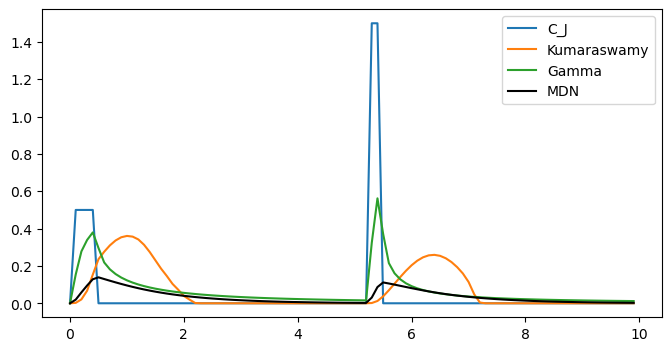

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(8,4))
ax.plot(data_df['C_J'], label='C_J')
ax.plot(data_df.index, C_Q_final1, label='Kumaraswamy')
ax.plot(data_df.index, C_Q_final2, label='Gamma')
ax.plot(data_df.index, C_Q_final3, 'k', label='MDN')
ax.legend()


# Compute gradients and Jacobian

In [27]:
def evolve_C_Q(sas_Q, sas_ET):
    sT_final, mT_final, mQETs_final, pQETs_final, C_Q_final = solve_sas(
            solve_ttd_sTmT, solve_step_rk4, fvec,
            J_full, C_J, Q, ET, dt,
            sTmT_0, ST_top_0, ST_bot_0, sTmT_init,  
            sas_Q, sas_ET,
            α_Q, α_ET, k1, C_eq, C_old, P_Q_old,
            # solve_ttd_func=solve_ttd_sTmT, solver=solve_step_rk4, f=fvec
    )
    # return C_Q_final.sum()
    return C_Q_final


## Kumaraswamy

In [28]:
jac1 = eqx.filter_jacfwd(evolve_C_Q)(sas_Q1, sas_ET1)

FloatingPointError: invalid value (nan) encountered in jit(scan). Because jax_config.debug_nans.value and/or config.jax_debug_infs is set, the de-optimized function (i.e., the function as if the `jit` decorator were removed) was called in an attempt to get a more precise error message. However, the de-optimized function did not produce invalid values during its execution. This behavior can result from `jit` optimizations causing the invalid value to be produced. It may also arise from having nan/inf constants as outputs, like `jax.jit(lambda ...: jax.numpy.nan)(...)`. 

It may be possible to avoid the invalid value by removing the `jit` decorator, at the cost of losing optimizations. 

If you see this error, consider opening a bug report at https://github.com/jax-ml/jax.

## Gamma

In [29]:
jac2 = eqx.filter_jacfwd(evolve_C_Q)(sas_Q2, sas_ET2)
jac2

SAS_Gamma(loc=f64[100,1], scale=f64[100,1], a=f64[100,1])

[Text(0.5, 1.0, '$\\partial C_Q / \\partial a$ (Gamma distribution with $a=0.5$)'),
 Text(0.5, 0, 'Time')]

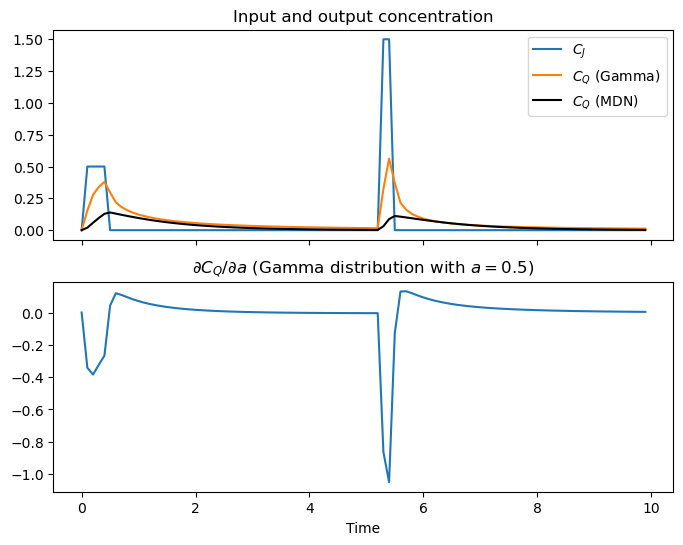

In [30]:
fig, axes = plt.subplots(2, 1, figsize=(8,6), sharex=True)

ax = axes[0]
ax.plot(data_df['C_J'], label='$C_J$')
# ax.plot(data_df.index, C_Q_final1, label='$C_Q$ (Kumaraswamy)')
ax.plot(data_df.index, C_Q_final2, label='$C_Q$ (Gamma)')
ax.plot(data_df.index, C_Q_final3, 'k', label='$C_Q$ (MDN)')
ax.legend()
ax.set(title='Input and output concentration')

ax = axes[1]
ax.plot(data_df.index, jac2.a, label='$\partial C_Q / \partial a$')
ax.set(title='$\partial C_Q / \partial a$ (Gamma distribution with $a=0.5$)', xlabel='Time')


## MDN

In [31]:
jac3 = eqx.filter_jacfwd(evolve_C_Q)(sas_Q3, sas_ET3)
jac3

SAS_MDN(
  loc=f64[100,1],
  scale=f64[100,1],
  m=MLP(
    layers=(
      Linear(
        weight=f64[100,1,20,1],
        bias=f64[100,1,20],
        in_features=1,
        out_features=20,
        use_bias=True
      ),
      Linear(
        weight=f64[100,1,20,20],
        bias=f64[100,1,20],
        in_features=20,
        out_features=20,
        use_bias=True
      ),
      Linear(
        weight=f64[100,1,20,20],
        bias=f64[100,1,20],
        in_features=20,
        out_features=20,
        use_bias=True
      ),
      Linear(
        weight=f64[100,1,20,20],
        bias=f64[100,1,20],
        in_features=20,
        out_features=20,
        use_bias=True
      )
    ),
    activation=None,
    final_activation=None,
    use_bias=True,
    use_final_bias=True,
    in_size=1,
    out_size=20,
    width_size=20,
    depth=3
  ),
  m_α=Linear(
    weight=f64[100,1,5,20],
    bias=f64[100,1,5],
    in_features=20,
    out_features=5,
    use_bias=True
  ),
  m_μ=Linear(
    w